In [92]:
import numpy as np
import pandas as pd

In [93]:
df = pd.read_csv('spam.csv', encoding='latin1')

In [94]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [95]:
df.shape

(5572, 5)

In [96]:
# Data Cleaning
# EDA
# text preprocessing
# Model building
# Evaluation
# Improvement
# Website
# Deploy

In [97]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 677.1 KB


In [98]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [99]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [100]:
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [101]:
df['target'].value_counts()

target
ham     4825
spam     747
Name: count, dtype: int64

In [102]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])

In [103]:
df.isnull().sum()

target    0
text      0
dtype: int64

In [104]:
df.duplicated().sum()


np.int64(403)

In [105]:
df = df.drop_duplicates(keep = 'first')

In [106]:
df.shape

(5169, 2)

In [107]:
# EDA
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

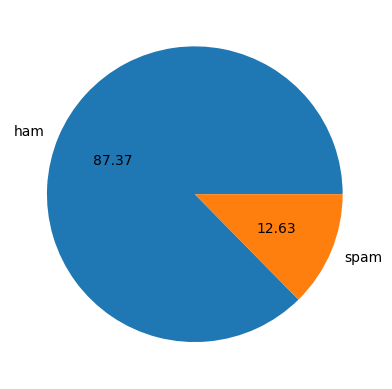

In [108]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [109]:
# data is imbalanced

In [110]:
!pip install nltk


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [111]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Saura\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Saura\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [112]:
df['num_characters'] = df['text'].apply(len)

In [113]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [114]:
# Number of words
df['num_words'] = df['text'].apply(lambda x : len(nltk.word_tokenize(x))) 

In [115]:
df['num_sentences'] = df['text'].apply(lambda x : len(nltk.sent_tokenize(x))) 

In [116]:
df.columns

Index(['target', 'text', 'num_characters', 'num_words', 'num_sentences'], dtype='str')

In [117]:
df[['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [118]:
df[df['target']==0][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [119]:
df[df['target']==1][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [120]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='num_characters', ylabel='Count'>

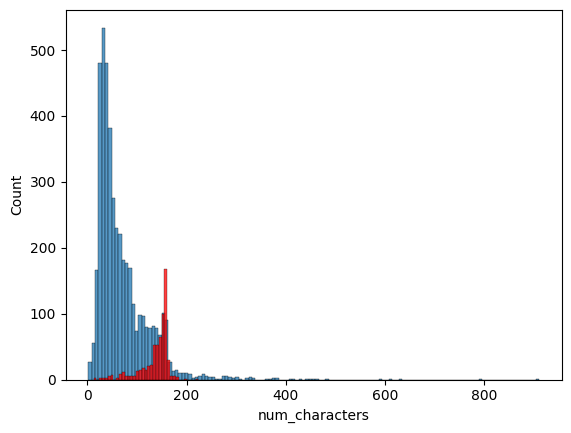

In [121]:
plt.Figure(figsize=(25,15))
sns.histplot(df[df['target']==0]['num_characters'])
sns.histplot(df[df['target']==1]['num_characters'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

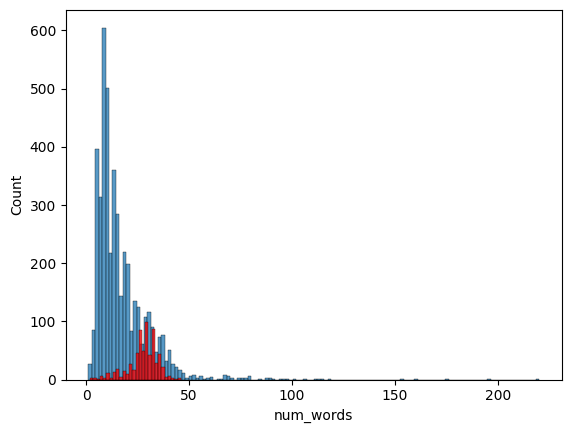

In [122]:
plt.Figure(figsize=(25,15))
sns.histplot(df[df['target']==0]['num_words'])
sns.histplot(df[df['target']==1]['num_words'],color='red')

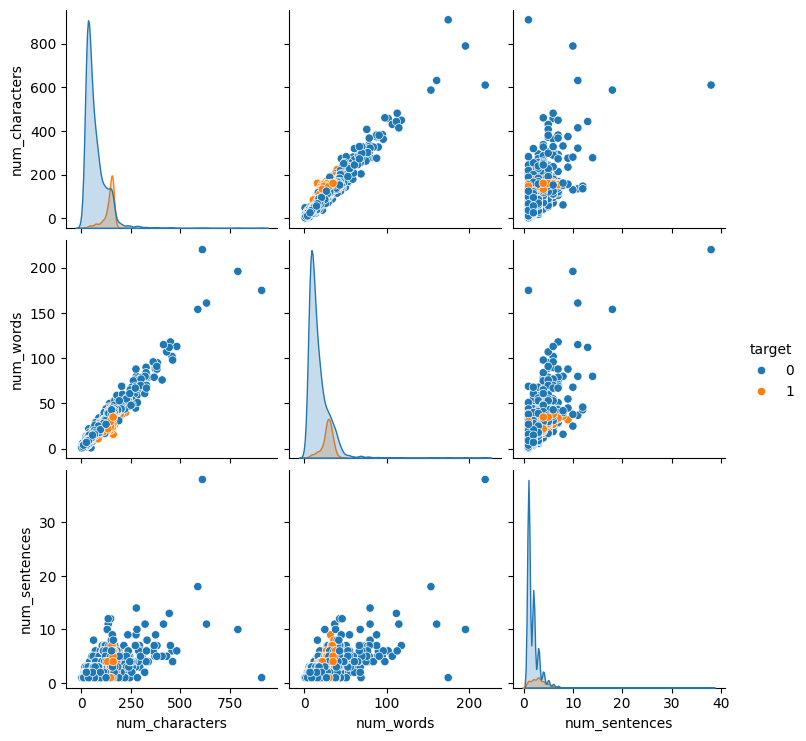

In [123]:
sns.pairplot(df,hue='target')

In [124]:
df.columns

Index(['target', 'text', 'num_characters', 'num_words', 'num_sentences'], dtype='str')

In [125]:
df[['target',  'num_characters', 'num_words', 'num_sentences']].corr()

,target,num_characters,num_words,num_sentences
target,1.000000,0.384717,0.262912,0.263939
num_characters,0.384717,1.000000,0.965760,0.624139
num_words,0.262912,0.965760,1.000000,0.679971
num_sentences,0.263939,0.624139,0.679971,1.000000


<Axes: >

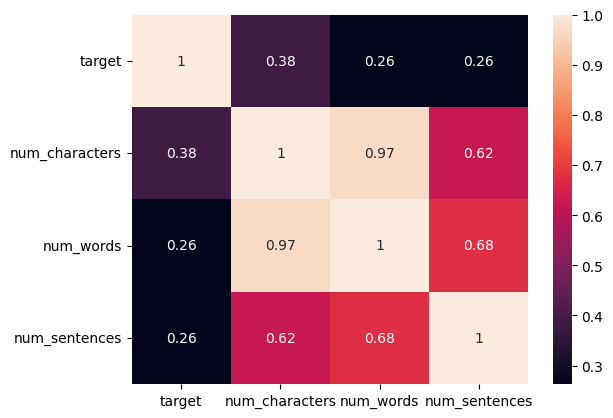

In [126]:
sns.heatmap(df[['target',  'num_characters', 'num_words', 'num_sentences']].corr(),annot=True)

In [127]:
# Data Preprocessing
# Lower Case
# Removing special characters
# Removing stop words and punctuation
# Stemming 
import string
from nltk.corpus import stopwords
nltk.download('stopwords')
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
# ps.stem('loving')
# stopwords.words('english')
# string.punctuation


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Saura\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [128]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    
    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)

In [129]:
transform_text(df['text'][200])

'sent lt gt buck'

In [130]:
df['transformed_text']= df['text'].apply(transform_text)

In [131]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [132]:
# !pip install wordcloud


In [133]:
from wordcloud import WordCloud
wc = WordCloud(width=500 , height=500 , min_font_size=10,background_color='white')

In [134]:
spam_wc  = wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep = " "))
ham_wc  = wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep = " "))

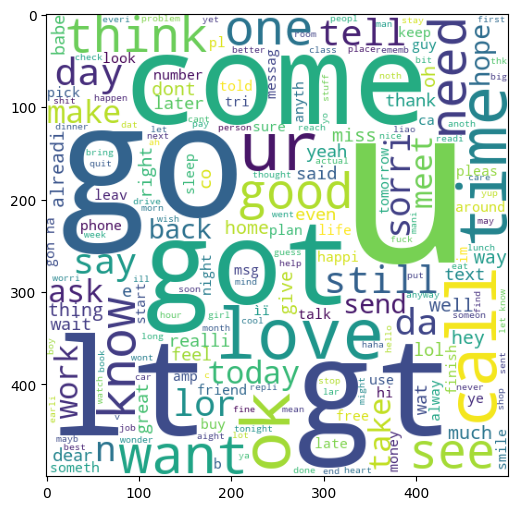

In [135]:
plt.figure(figsize=(12,6))
plt.imshow(spam_wc)

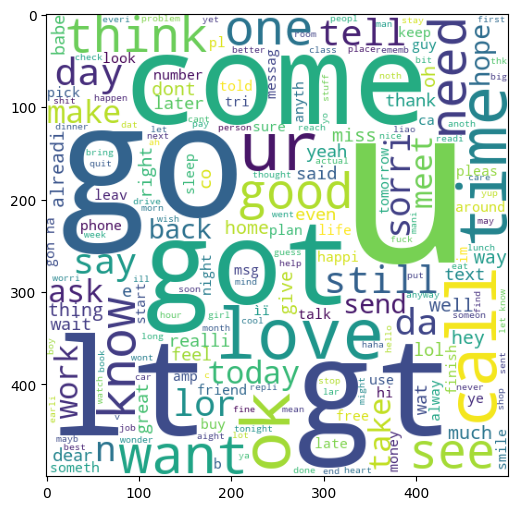

In [136]:
plt.figure(figsize=(12,6))
plt.imshow(ham_wc)

In [137]:
span_corpus = []
for msg in df[df['target']==1]['transformed_text'].tolist():
    for word in msg.split():
        span_corpus.append(word)

In [138]:
len(span_corpus)

9939

In [139]:
from collections import Counter
mst_cmn = pd.DataFrame(Counter(span_corpus).most_common(30))
mst_cmn

,0,1
0,call,320
1,free,191
2,2,155
3,txt,141
4,text,122
5,u,119
6,ur,119
7,mobil,114
8,stop,104
9,repli,103


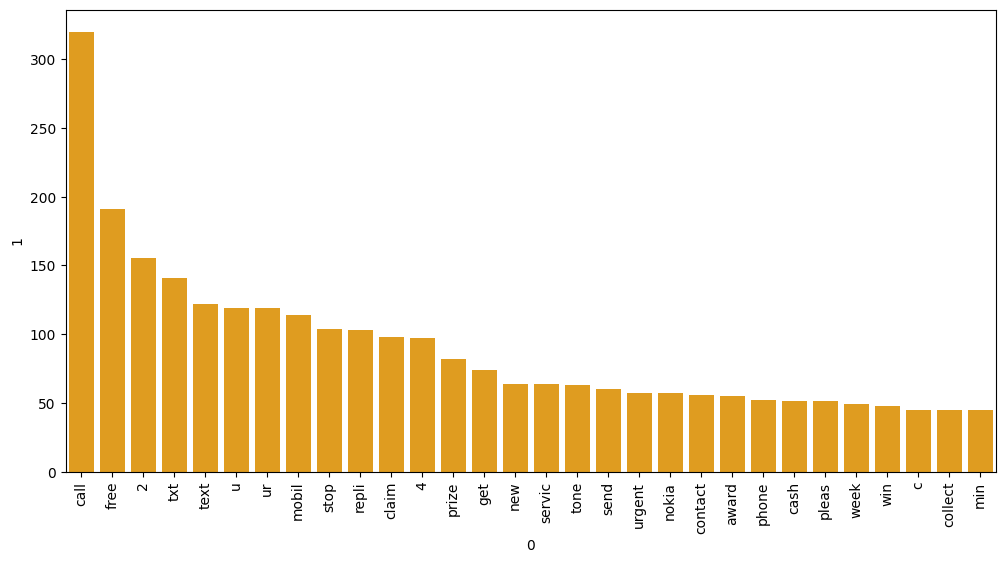

In [140]:
plt.figure(figsize=(12,6))
sns.barplot(x = mst_cmn[0], y =mst_cmn[1], color='orange')
plt.xticks(rotation = 'vertical')
plt.show()

In [141]:
han_corpus = []
for msg in df[df['target']==0]['transformed_text'].tolist():
    for word in msg.split():
        han_corpus.append(word)

In [142]:
len(han_corpus)

35404

In [143]:
mst_cmn_han = pd.DataFrame(Counter(han_corpus).most_common(30))
mst_cmn_han

,0,1
0,u,883
1,go,404
2,get,349
3,gt,288
4,lt,287
5,2,284
6,come,275
7,got,236
8,know,236
9,like,234


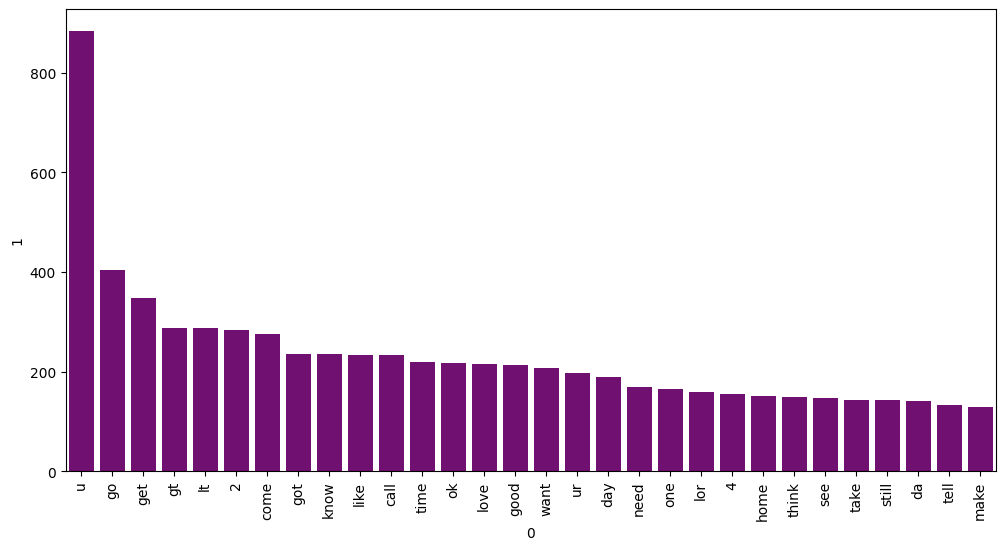

In [144]:
plt.figure(figsize=(12,6))
sns.barplot(x = mst_cmn_han[0], y = mst_cmn_han[1], color='purple')
plt.xticks(rotation = 'vertical')
plt.show()

In [145]:
#Model Building
 

In [146]:
# 1 -> from sklearn.feature_extraction.text import CountVectorizer (Bag of Words)
# cv = CountVectorizer()
from sklearn.feature_extraction.text import TfidfVectorizer
# tfidf = TfidfVectorizer()
tfidf = TfidfVectorizer(max_features=3000)#had experimented and figured our 3000 is best


In [147]:
# X = cv.fit_transform(df['transformed_text']).toarray()
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [148]:
# from sklearn.preprocessing import MinMaxScaler #Scaling done in order to correct the algorithms
# scaler = MinMaxScaler()
# X = scaler.fit_transform(X)
# commenting scalar because it was not giving fruitful results

In [149]:
X.shape

(5169, 3000)

In [150]:
y = df['target'].values

In [151]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [152]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [153]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [154]:
# gnb.fit(X_train,y_train)
# y_pred1 = gnb.predict(X_test)
# print(accuracy_score(y_test,y_pred1))
# print(confusion_matrix(y_test,y_pred1))
# print(precision_score(y_test,y_pred1))

In [155]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9709864603481625
[[896   0]
 [ 30 108]]
1.0


In [156]:
# bnb.fit(X_train,y_train)
# y_pred3 = bnb.predict(X_test)
# print(accuracy_score(y_test,y_pred3))
# print(confusion_matrix(y_test,y_pred3))
# print(precision_score(y_test,y_pred3))

In [157]:
# we will choose tfidf --> MNB

In [158]:
# Now test will all classification algorithms for comaring results
# !pip install xgboost

In [159]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.svm import SVC
# from sklearn.naive_bayes import MultinomialNB
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.ensemble import AdaBoostClassifier
# from sklearn.ensemble import BaggingClassifier
# from sklearn.ensemble import ExtraTreesClassifier
# from sklearn.ensemble import GradientBoostingClassifier
# from xgboost import XGBClassifier

In [160]:
# svc = SVC(kernel='sigmoid',gamma=1.0)
# knc = KNeighborsClassifier()
# mnb = MultinomialNB()
# dtc = DecisionTreeClassifier(max_depth=5)
# lrc = LogisticRegression(solver='liblinear',penalty='l1')
# rfc = RandomForestClassifier(n_estimators=50,random_state=2)
# abc = AdaBoostClassifier(n_estimators=50 , random_state=2)
# bc = BaggingClassifier(n_estimators=50,random_state=2)
# etc = ExtraTreesClassifier(n_estimators=50,random_state=2)
# gbdt = GradientBoostingClassifier(n_estimators=50, random_state=2)
# xgb = XGBClassifier(n_estimators=50, random_state=2)


In [161]:
# clfs = {
#     'SVC' : svc,
#     'KN'  : knc,
#     'NB'  : mnb,
#     'DT'  : dtc,
#     'LR'  : lrc,
#     'RF'  : rfc,
#     'AdaBoost' : abc,
#     'BgC' : bc,
#     'ETC' : etc,
#     'GBDT' : gbdt,
#     'xgb'  : xgb
# }

In [162]:
# def train_classifier(clf,X_train,y_train,X_test,y_test):
#     clf.fit(X_train,y_train)
#     y_pred = clf.predict(X_test)
#     accuracy = accuracy_score(y_test,y_pred)
#     precision = precision_score(y_test,y_pred)

#     return accuracy,precision

In [163]:
# Example below
# x1,x2 = train_classifier(svc,X_train,y_train,X_test,y_test)


In [164]:
# print(x1," ---->  ",x2)

In [165]:
# accuracy_scores = []
# precision_scores = []

# for name,clf in clfs.items():
#     current_accuracy,current_precision = train_classifier(clf,X_train,y_train,X_test,y_test)

#     print("For ",name)
#     print("Accuracy - ",current_accuracy)
#     print("Precision - ",current_precision)

#     accuracy_scores.append(current_accuracy)
#     precision_scores.append(current_precision)

In [166]:
# performance_df = pd.DataFrame({'Algorithms': clfs.keys(),'Accuracy':accuracy_scores , 'Precision':precision_scores})

In [167]:
# performance_df.sort_values(by=['Precision', 'Accuracy'],ascending=[False, False])

In [168]:
# performance_df3 = pd.melt(performance_df,id_vars="Algorithms")

In [169]:
# performance_df2 = pd.melt(performance_df,id_vars="Algorithms")

In [170]:
# performance_df2.rename(columns={'value':'value2'},inplace=True)
# performance_df2

In [171]:
# result = pd.merge(result, performance_df3, on=['Algorithms','variable'])
# result

In [172]:
# performance_df1 = pd.melt(performance_df,id_vars="Algorithms")


In [173]:
# performance_df1

In [174]:
# sns.catplot(x = 'Algorithms',y='value' ,hue = 'variable' ,data=performance_df1,kind='bar',height=5)
# plt.ylim(0.5,1.0)
# plt.xticks(rotation = 'vertical')
# plt.show()

In [175]:
# model improve
# 1. Change the max_feature paramenter of TfIdf(Most used words)

In [176]:
# # Voting Classifier 
# svc = SVC(kernel='sigmoid',gamma=1.0,probability=True)
# mnb = MultinomialNB()
# etc = ExtraTreesClassifier(n_estimators=50,random_state=2)
# from sklearn.ensemble import VotingClassifier

In [177]:
# voting = VotingClassifier(estimators=[('svm',svc),('nb',mnb),('et',etc)],voting='soft')

In [178]:
# voting.fit(X_train,y_train)

In [179]:
# y_pred = voting.predict(X_test)
# print("Accuracy",accuracy_score(y_test,y_pred))
# print("Precision",precision_score(y_test,y_pred))

In [180]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))